[Sascha Spors](https://orcid.org/0000-0001-7225-9992),
Professorship Signal Theory and Digital Signal Processing,
[Institute of Communications Engineering (INT)](https://www.int.uni-rostock.de/),
Faculty of Computer Science and Electrical Engineering (IEF),
[University of Rostock, Germany](https://www.uni-rostock.de/en/)

# Tutorial Signals and Systems (Signal- und Systemtheorie)

Summer Semester 2022 (Bachelor Course #24015)

- lecture: https://github.com/spatialaudio/signals-and-systems-lecture
- tutorial: https://github.com/spatialaudio/signals-and-systems-exercises

Feel free to contact lecturer [frank.schultz@uni-rostock.de](https://orcid.org/0000-0002-3010-0294)

## Task 10.4 

DTFT windowing

In [1]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import numpy as np
from scipy.special import diric

In [2]:
Nf = 2**10  # values along frequency axis
# get frequency vector for plotting of DTFT
Om = np.arange(-2*Nf, 2*Nf) * (2*np.pi/Nf)


def plot_rect_psinc(k, x1, x2, Om, X1, X2):
    plt.figure(figsize=(8, 6))
    ax = plt.subplot(3, 2, 1)
    plt.plot(k, np.real(x1), 'C0o:', label=r'$\Re$')
    plt.plot(k, np.imag(x1), 'C1o:', label=r'$\Im$')
    plt.stem(k, np.real(x1), use_line_collection=True,
             linefmt='C0--', markerfmt='C0o', basefmt='C0:')
    plt.stem(k, np.imag(x1), use_line_collection=True,
             linefmt='C1--', markerfmt='C1o', basefmt='C1:')
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.xlabel(r'$k$')
    plt.ylabel(r'$w[k] x_1[k]$')
    plt.legend(loc='lower left')
    plt.grid(True)

    ax = plt.subplot(3, 2, 3)
    plt.plot(k, np.real(x2), 'C0o:', label=r'$\Re$')
    plt.plot(k, np.imag(x2), 'C1o:', label=r'$\Im$')
    plt.stem(k, np.real(x2), use_line_collection=True,
             linefmt='C0--', markerfmt='C0o', basefmt='C0:')
    plt.stem(k, np.imag(x2), use_line_collection=True,
             linefmt='C1--', markerfmt='C1o', basefmt='C1:')
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.xlabel(r'$k$')
    plt.ylabel(r'$w[k] x_2[k]$')
    plt.legend(loc='lower left')
    plt.grid(True)

    ax = plt.subplot(3, 2, 5)
    plt.plot(k, np.real(x1+x2), 'C0o:', label=r'$\Re$')
    plt.plot(k, np.imag(x1+x2), 'C1o:', label=r'$\Im$')
    plt.stem(k, np.real(x1+x2), use_line_collection=True,
             linefmt='C0--', markerfmt='C0o', basefmt='C0:')
    plt.stem(k, np.imag(x1+x2), use_line_collection=True,
             linefmt='C1--', markerfmt='C1o', basefmt='C1:')
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.xlabel(r'$k$')
    plt.ylabel(r'$w[k] (x_1[k]+x_2[k])$')
    plt.legend(loc='lower left')
    plt.grid(True)

    ax = plt.subplot(3, 2, 2)
    plt.plot([2, 2], [0, 9], 'C2', lw=1)
    plt.plot([3, 3], [0, 9], 'C3', lw=1)
    plt.plot(Om/(np.pi/4), np.abs(X1), 'C2')
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    plt.xlim(-6, +11)
    plt.ylim(0, 9)
    plt.xlabel(r'$\Omega \,\,/\,\, (\pi/4)$')
    plt.ylabel(r'$|X_{w,1}(\Omega)|$')
    plt.grid(True)

    ax = plt.subplot(3, 2, 4)
    plt.plot([2, 2], [0, 9], 'C2', lw=1)
    plt.plot([3, 3], [0, 9], 'C3', lw=1)
    plt.plot(Om/(np.pi/4), np.abs(X2), 'C3')
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    plt.xlim(-6, +11)
    plt.ylim(0, 9)
    plt.xlabel(r'$\Omega \,\,/\,\, (\pi/4)$')
    plt.ylabel(r'$|X_{w,2}(\Omega)|$')
    plt.grid(True)

    ax = plt.subplot(3, 2, 6)
    plt.plot([2, 2], [0, 9], 'C2', lw=1)
    plt.plot([3, 3], [0, 9], 'C3', lw=1)
    plt.plot(Om/(np.pi/4), np.abs(X1+X2), 'k')
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    plt.xlim(-6, +11)
    #plt.ylim(0, 9)
    plt.xlabel(r'$\Omega \,\,/\,\, (\pi/4)$')
    plt.ylabel(r'$|X_{w,1}(\Omega)+X_{w,2}(\Omega)|$')
    plt.grid(True)

    plt.tight_layout()

# Sum Complex Exponentials

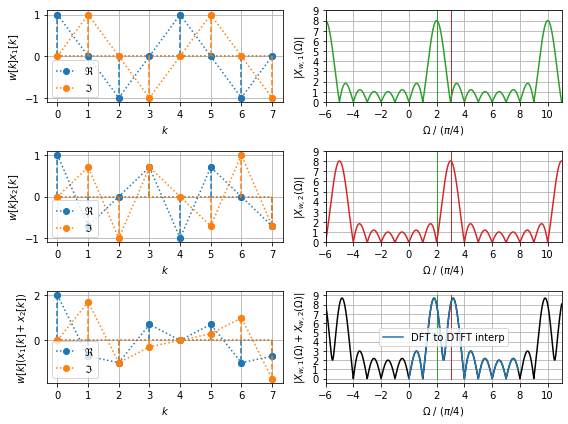

In [3]:
N = 8

k = np.arange(N)

Om1 = 2*np.pi/N * 2
Om2 = 2*np.pi/N * 3

x1 = np.exp(+1j*Om1*k)
X1 = diric((Om-Om1), N)*N * np.exp(-1j*(Om-Om1)*(N-1)/2)  # DTFT of x1[k]

x2 = np.exp(+1j*Om2*k)
X2 = diric((Om-Om2), N)*N * np.exp(-1j*(Om-Om2)*(N-1)/2)  # DTFT of x2[k]

plot_rect_psinc(k, x1, x2, Om, X1, X2)

plt.savefig('windowing_96D7F1EE47.pdf')

dft_chk = True
if dft_chk:
    Nfft = 2**6
    X = np.fft.fft(x1+x2, Nfft)
    Omfft = np.arange(Nfft) * 2*np.pi/Nfft
    plt.plot(Omfft/(np.pi/4), np.abs(X), 'C0', label='DFT to DTFT interp')
    plt.legend()

Text(0.5, 0, '$\\Omega$')

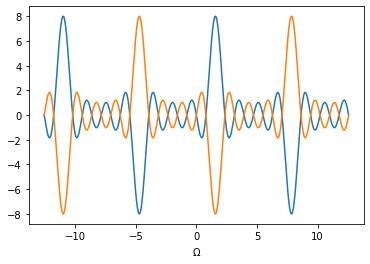

In [4]:
mu = 1
Xtst = diric((Om-Om1), N)*N * np.exp(-1j*(Om-Om1)*(N-1)/2)
Xtst_mu = diric((Om-Om1+2*np.pi*mu), N)*N * \
    np.exp(-1j*(Om-Om1+2*np.pi*mu)*(N-1)/2)
np.allclose(Xtst, Xtst_mu)
if True:
    plt.plot(Om, diric((Om-Om1), N)*N)
    plt.plot(Om, diric((Om-Om1+2*np.pi*mu), N)*N)
if False:
    plt.plot(Om, np.real(np.exp(-1j*(Om-Om1)*(N-1)/2)))
    plt.plot(Om, np.real(np.exp(-1j*(Om-Om1+2*np.pi*mu)*(N-1)/2)))
if False:
    plt.plot(Om, np.imag(np.exp(-1j*(Om-Om1)*(N-1)/2)))
    plt.plot(Om, np.imag(np.exp(-1j*(Om-Om1+2*np.pi*mu)*(N-1)/2)))
plt.xlabel(r'$\Omega$')

## Copyright

This tutorial is provided as Open Educational Resource (OER), to be found at
https://github.com/spatialaudio/signals-and-systems-exercises
accompanying the OER lecture
https://github.com/spatialaudio/signals-and-systems-lecture.
Both are licensed under a) the Creative Commons Attribution 4.0 International
License for text and graphics and b) the MIT License for source code.
Please attribute material from the tutorial as *Frank Schultz,
Continuous- and Discrete-Time Signals and Systems - A Tutorial Featuring
Computational Examples, University of Rostock* with
``github URL, commit number and/or version tag, year, (file name and/or content)``.